Efectos de la atmósfera terrestre sobre la radiación que llega del espacio
===

Alumno
---
Pedro G. Villegas

Docentes
---
J.P. Calderón & R. Gamen

Resumen
---
Cuando observamos una fuente astronómica con un telescopio en la Tierra, la atmósfera afecta la radiación que recibimos. Existen maneras de caracterizar este efecto. En esta práctica aprenderemos uno de ellos.

Recuerden leer la bibliografía accesible desde la Wiki de la materia [Wiki:Unidad 3](http://astronomiaestelarlp.pbworks.com/w/page/106869798/Programa%20de%20la%20materia).

Objetivos
---
* Obtener la fotometría de apertura de una series de imagenes obtenidas en el Complejo Astronómico El Leoncito, San Juan, en noviembre de 2015. 
* Determinar la pendiente de la ecuación de la Ley de Bouguer para cada uno de los filtros disponibles.

Los pasos que vamos a seguir son:

1. **Introducción**
    1. [Inspección visual de las imagenes](#inspeccion)
    2. [Identificación de las estrellas a medir](#identificacion)
    3. [Grafico de la curva de crecimiento](#curva_de_crecimiento)
    
2. **Fotometría de apertura**
    1. [Usando ```phot utils``` ](#como_funciona)
    2. [¡A medir!](#a_medir)
    3. [Ajuste del modelo lineal](#ley_de_bouguer)

Referencias
---
* [Baume, G., Coronel, C., De Bórtoli, B., et al. (2017)](http://adsabs.harvard.edu/abs/2017BAAA...59...46B)
* [Landolt, A. U.: (1992)](http://adsabs.harvard.edu/abs/1992AJ....104..340L)
* [Listado de estrellas estandard (ESO)](https://www.eso.org/sci/observing/tools/standards.html)

* [Práctica 03 (overleaf)](https://www.overleaf.com/read/npkyvfvnssds)

---

In [2]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

<a id='inspeccion'></a>
## A. Despliegue una de las imágenes en el DS9. Identifique las estrellas estándares del campo de T Phoenicis (TPHE). Comparando con las indicadas en el trabajo de Landolt (1992).

In [4]:
imagen = 'tphe_v01s.fits'
with fits.open(imagen) as hdul:
    hdul.info() #Esto me dice la información que posee la imagen
    hdr = hdul[0].header  # defino hdr como la variable con el contenido del header -> Encabezado, información de la imagen.
    data = hdul[0].data   # defino data con el contenido de la imagen

Filename: tphe_v01s.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      71   (409, 411)   float32   


In [5]:
hdr  # para "ver" una variable simplemente tipeo su nombre
# Puedo poner hdr['SIMPLE'] para que me devuelva el valor de ese dato

SIMPLE  =                    T / Fits standard                                  
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                  409 / Axis length                                    
NAXIS2  =                  411 / Axis length                                    
EXTEND  =                    F / File may contain extensions                    
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
DATE    = '2016-08-30T14:18:20' / Date FITS file was generated                  
IRAF-TLM= '2017-03-08T19:38:43' / Time of last modification                     
OBJECT  = 'TPHE    '           / Name of the object observed                    
CCDSIZE = '[1:2048,1:2058] '     / CCD size                                     
CCDSUM  = '5 5 '                 / CCD binning factors                          
PIXSIZE1=                 13

In [6]:
# Determino variables estadísticas de la imagen

data_min = data.min()
data_max = data.max()
data_mean = data.mean()
data_std = data.std()

print ( data_min, data_max, data_mean, data_std )

0.0 55449.273 136.52036 384.5497


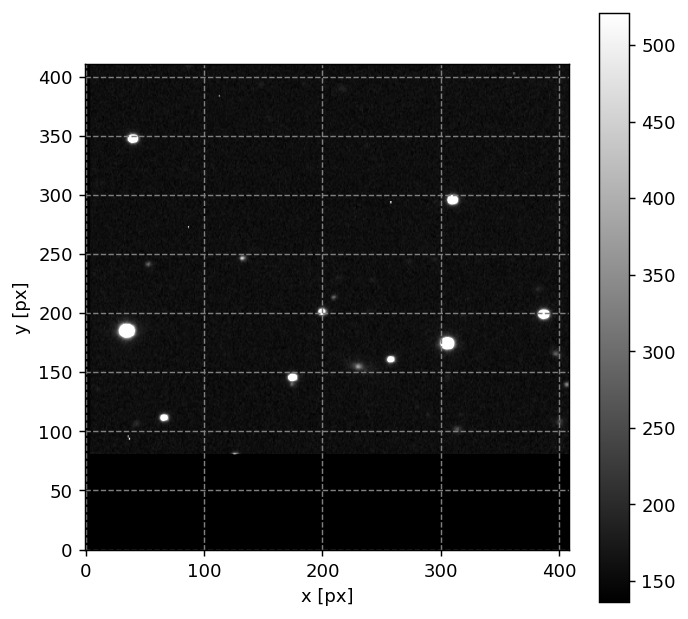

In [7]:
# Le indico entre qué valores z1 (=vmin) y z2 (=vmax) quiero "ver", y despliego la imagen dentro de notebook

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (6, 6), dpi = 130 )

im = ax.imshow ( data, origin = 'lower',  vmin = data_mean - 0*data_std, 
                vmax = data_mean + 1*data_std, cmap = 'gray')
fig.colorbar(im)

ax.set_xlabel ( 'x [px]' )
ax.set_ylabel ( 'y [px]' )
plt.grid ( color = 'gray', linestyle = 'dashed' )

plt.show()

In [8]:
# Esta celda no es necesaria. Es simplemente una muestra de cómo conectar DS9 con el notebook, pero hay que revisarla para este SO
# Abrir el ds9, desde la terminal de CONDA.
# ejemplo: $ ds9 -title "practica00" &
#import imexam #hay que instalarlo, supuestamente con conda install imexam
#import os

#os.environ['$XPA_METHOD'] = "local" # para conectarlo a ds9
#windows = imexam.list_active_ds9()

#if windows:
#    a = imexam.connect(windows.popitem()[0])
#else:
#    print ( 'No encuentro el DS9 abierto.' )

In [9]:
# Idem el comentario de la celda anterior
#a.load_fits ( 'tphe_v01s.fits' )
#a.scale()

<a id='identificacion'></a>
## B. Hay que identificar las estrellas que queremos medir.

![](./tphe.jpg)

In [10]:
# Completar con las coordenadas (x, y) de cada estrella en orden: A, B, C, D

positions = [ (311.29862,296.65398), # COMPLETAR
              (36.099911,186.47298),
              (388.16112,200.2489),
              (306.933,175.75727)]
positions[0]

(311.29862, 296.65398)

In [11]:
# Esto imprime las coordenadas x primero y las y después

for i in zip(*positions):
    print (i)

(311.29862, 36.099911, 388.16112, 306.933)
(296.65398, 186.47298, 200.2489, 175.75727)


In [12]:
list(zip(*positions))

[(311.29862, 36.099911, 388.16112, 306.933),
 (296.65398, 186.47298, 200.2489, 175.75727)]

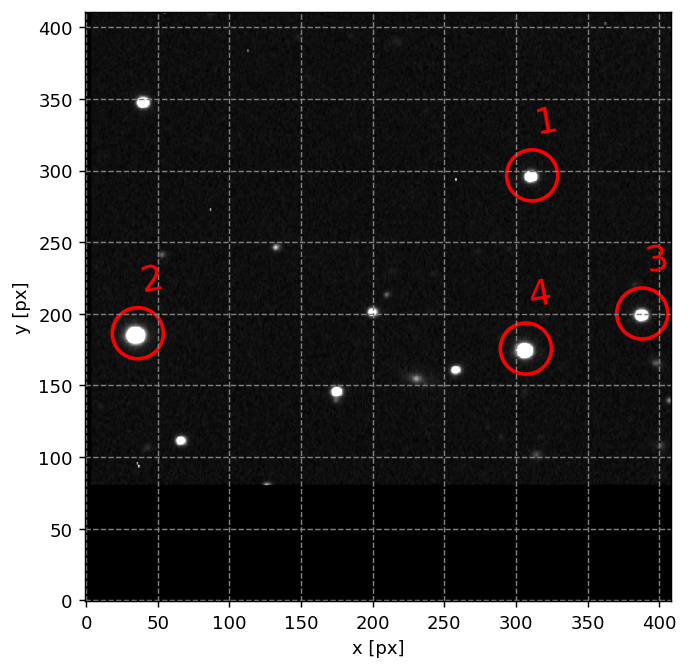

In [13]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (6, 6), dpi = 130 )

ax.imshow ( data, origin = 'lower',  vmin = data_mean - 0*data_std, 
                vmax = data_mean + 1*data_std, cmap = 'gray' )

# Grafico los circulos usando las coordenadas de la _lista_ positions
# La función _zip_ toma los valores (x,y) de la lista y lo pasa como un único valor
ax.scatter ( *list(zip(*positions)), s = 800, linewidths = 2 , facecolors = 'none', edgecolors = 'red' )

# Grafico el _id_ de la estrella: A==1, B==2, C==3, D==4
for i in [ 1, 2, 3, 4 ]:
    ax.annotate(str(i), color = "red", xy = positions[i-1],
                xytext = (0, 30), textcoords = 'offset points', 
                va = "center", rotation = 10, size = 20 )

ax.set_xlabel ( 'x [px]' )
ax.set_ylabel ( 'y [px]' )
plt.grid ( color = 'gray', linestyle = 'dashed' )

plt.show()

<a id='curva_de_crecimiento'></a>
## C. Curva de crecimiento

Ver _notebook_ correspondiente.

Las curvas de crecimiento son para ver, sobre una determinada estrella, de qué diametro es conveniente hacer
el circulo que medirá la magnitud de la estrella y el anillo que medirá el aporte del cielo.
Según el notebook, la apertura optima es de 16

<a id='como_funciona'></a>
# Usando ```phot utils``` para medir muchas estrellas (e imágenes) a la vez 
---
## A. ¿Cómo funciona?

Vamos a hacer una prueba con una sola imagen, midiendo las cuatro estrellas identificadas.

In [15]:
#!conda install photutils pos no descarga
#!conda install -y -c conda-forge photutils

 id  xcenter   ycenter    aperture_sum_0     aperture_sum_1 
       pix       pix                                        
--- --------- --------- ------------------ -----------------
  1 311.29862 296.65398  167245.4266708869 78107.24098748446
  2 36.099911 186.47298  879454.6979646015 81012.43602674619
  3 388.16112  200.2489 193982.31625813464 78222.51375476309
  4   306.933 175.75727  480854.8969087363 79129.35657997207


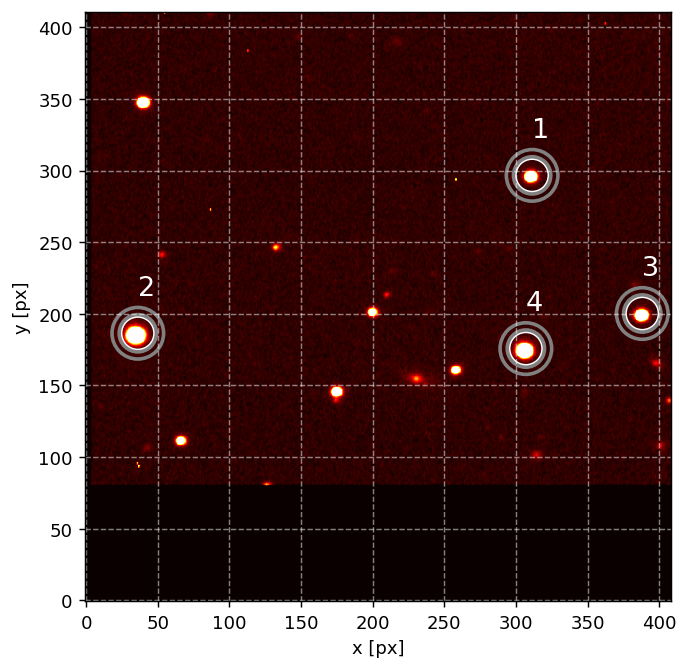

In [16]:
from photutils import CircularAperture, CircularAnnulus
from photutils import aperture_photometry
from astropy.io import fits
import pandas as pd
import numpy as np

imagen = 'tphe_v01s.fits'

with fits.open(imagen) as hdul:
    hdr = hdul[0].header  
    data = hdul[0].data  
    
aperture = CircularAperture ( positions, r = 12. )
anncielo = CircularAnnulus ( positions, r_in = 13, r_out = 18 ) 
apers = [ aperture, anncielo ]

phot_table = aperture_photometry ( data, apers )
print(phot_table)

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (6, 6), dpi = 130 )
ax.imshow ( data, origin = 'lower', vmin = data.mean() - 0*data.std(), 
                 vmax = data.mean() + 1*data.std(), cmap = 'hot' )

for i in [ 1, 2, 3, 4 ]:
    ax.annotate(str(i), color = "white", xy = positions[i-1],
                xytext = (0, 25), textcoords = 'offset points', 
                va = "center", rotation = 0, size = 15 )

ax.set_xlabel ( 'x [px]' )
ax.set_ylabel ( 'y [px]' )

aperture.plot ( color = 'white', linewidth = 2 )
anncielo.plot ( color = 'gray', linewidth = 2 )

plt.grid ( color = 'white', linestyle = '--', alpha = 0.5 )

plt.show()

Si tomamos como $I_{C}$ a la intensidad de la imagen dentro del anillo de cielo, $A_{C}$ como el área de ese anillo. Entonces, $\lt I_{C}\gt$ corresponde a la intensidad media dentro de la apertura considerada:

\begin{equation}
\large \lt I_{C} \gt = I_{C}/A_{C}
\end{equation}

Luego, restamos la intensidad media del cielo a la intensidad de la apertura considerada $I_{A}$, con lo que obtengo la intensidad de las estrella $I_{S}$ sin las contribución del cielo:

\begin{equation}
\large I_{S} = I_{A} - \lt I_{C} \gt
\end{equation}

Por último, paso la intensidad de la estrella a magnitudes:

\begin{equation}
\large m = 25 - 2.5 \ log(I_{S})
\end{equation}

Dónde el termino independiente se utiliza para obtener un valor de la magnitud típico. Esta magnitud corresponde a la instrumental.

In [ ]:
# Background Mean (<Ic>) = Ic/Ac
bkg_mean = phot_table['aperture_sum_1'] / anncielo.area # ADUs por pixel en el cielo, calculado dentro del anillo
bkg_sum = bkg_mean * aperture.area                   # ADUs totales del cielo dentro de la apertura de la estrella
# Calculé la media de intensidad del cielo dentro del anillo, y despues la multipliqué por el area del circulo de la estrella
#para saber cuál sería la contribución total (aproximada) sobre el mismo

phot_table['flux corrected'] = phot_table['aperture_sum_0'] - bkg_sum # ADUs provenientes de la estrella
 
phot_table['magnitud'] = 25.0 - 2.5 * np.log10( phot_table['flux corrected'] / hdr['EXPTIME'] ) 
phot_table['airmass'] = hdr['AIRMASS']
phot_table['date'] = hdr['DATE-OBS']
phot_table['time'] = hdr['TIME-OBS']

phot_table

id,xcenter,ycenter,aperture_sum_0,aperture_sum_1,flux corrected,magnitud,airmass,date,time
,pix,pix,,,,,,,
int32,float64,float64,float64,float64,float64,float64,float64,str10,str10
1,311.29862,296.65398,167245.4266708869,78107.24098748446,94681.28020509488,16.252142833094396,1.04,2015-11-28,01:01:50.4
2,36.099911,186.47298,879454.6979646015,81012.43602674619,804191.5315913663,13.929404397990927,1.04,2015-11-28,01:01:50.4
3,388.16112,200.2489,193982.31625813464,78222.51375476309,121311.07767306441,15.983051984743657,1.04,2015-11-28,01:01:50.4
4,306.933,175.75727,480854.8969087363,79129.35657997207,407341.1720860526,14.667907365045386,1.04,2015-11-28,01:01:50.4


<a id='a_medir'></a>
## B. ¡a medir!

Ahora que entendemos qué es la fotometría de apertura, podemos continuar midiendo las tres imágenes de cada filtro.

In [18]:
from astropy.io import fits
from photutils import CircularAperture, CircularAnnulus
from photutils import aperture_photometry
from astropy.stats import sigma_clipped_stats
import numpy as np
import pandas as pd

fotometria = pd.DataFrame()
table_tmp = pd.DataFrame()

for filter in [ 'u', 'v', 'b', 'r', 'i' ]: # For sobre los filtros
    for order in [ '01', '02', '03' ]: # For sobre el número de imagen
        
        imagen = 'tphe_'+ filter + order + 's.fits' # 'tphe_v03s.fits'
        print ( "[+] Procesando imagen: " + imagen )
        with fits.open(imagen) as hdul:
            hdr = hdul[0].header  
            data = hdul[0].data   

        aperture = CircularAperture ( positions, r = 16. )
        anncielo = CircularAnnulus ( positions, r_in = 16, r_out = 18 ) # positions, r_in, r_out
        
        apers = [ aperture, anncielo ]
    
        phot_table = aperture_photometry ( data, apers )
  
        bkg_mean = phot_table['aperture_sum_1'] / anncielo.area # ADUs por pixel en el cielo
        bkg_sum = bkg_mean * aperture.area            # ADUs totales del cielo dentro de la apertura de la estrella

        phot_table['flux corrected'] = phot_table['aperture_sum_0'] - bkg_sum # ADUs provenientes de la estrella
 
        phot_table['magnitud'] = 25.0 - 2.5 * np.log10( phot_table['flux corrected'] / hdr['EXPTIME'] ) 
        phot_table['airmass'] = hdr['AIRMASS']
        phot_table['filtro'] = filter
        phot_table['order'] = order
        
        # Convierto el Qtable 'phot_table' a pandas. Para saber el tipo de variable usar: fotometria.info()
        table_tmp = pd.DataFrame.from_records ( phot_table, 
                    columns = ['id', 'xcenter', 'ycenter', 'aperture_sum_0', 'aperture_sum_1', 
                                'flux corrected', 'magnitud', 'airmass', 'filtro', 'order'] )

        # Voy agregando las variables calculadas en cada loop al pandas 'fotometria'
        fotometria = fotometria.append ( table_tmp )

[+] Procesando imagen: tphe_u01s.fits
[+] Procesando imagen: tphe_u02s.fits
[+] Procesando imagen: tphe_u03s.fits
[+] Procesando imagen: tphe_v01s.fits
[+] Procesando imagen: tphe_v02s.fits
[+] Procesando imagen: tphe_v03s.fits
[+] Procesando imagen: tphe_b01s.fits
[+] Procesando imagen: tphe_b02s.fits
[+] Procesando imagen: tphe_b03s.fits
[+] Procesando imagen: tphe_r01s.fits
[+] Procesando imagen: tphe_r02s.fits
[+] Procesando imagen: tphe_r03s.fits
[+] Procesando imagen: tphe_i01s.fits
[+] Procesando imagen: tphe_i02s.fits
[+] Procesando imagen: tphe_i03s.fits


In [ ]:
fotometria #[['id','filtro','magnitud','airmass']]

,id,xcenter,ycenter,aperture_sum_0,aperture_sum_1,flux corrected,magnitud,airmass,filtro,order
0,1,311.29862 pix,296.65398 pix,1.897908e+05,39920.170909,3.950307e+04,20.013573,1.04,u,01
1,2,36.099911 pix,186.47298 pix,7.683784e+05,40936.616392,6.142641e+05,17.034262,1.04,u,01
2,3,388.16112 pix,200.2489 pix,6.848535e+05,41004.572600,5.304834e+05,17.193471,1.04,u,01
3,4,306.933 pix,175.75727 pix,1.729960e+05,40910.544180,1.897987e+04,20.809417,1.04,u,01
0,1,311.29862 pix,296.65398 pix,1.312894e+06,338110.164990,4.000823e+04,19.999777,1.15,u,02
1,2,36.099911 pix,186.47298 pix,1.840373e+06,337180.056525,5.709894e+05,17.113580,1.15,u,02
2,3,388.16112 pix,200.2489 pix,1.770216e+06,339381.897233,4.925428e+05,17.274040,1.15,u,02
3,4,306.933 pix,175.75727 pix,1.284750e+06,335822.069709,2.047914e+04,20.726871,1.15,u,02
0,1,311.29862 pix,296.65398 pix,2.792629e+06,732773.137280,3.395326e+04,20.420221,1.79,u,03
1,2,36.099911 pix,186.47298 pix,3.268121e+06,733002.669916,5.085811e+05,17.481524,1.79,u,03


In [27]:
# Filtro la tabla por el id de alguna de las estrellas para graficar.
fotometria_filtrada = fotometria [ (fotometria['id'] == 1) & (fotometria['filtro'] == 'u') ]
print ( fotometria_filtrada )

   id        xcenter        ycenter  aperture_sum_0  aperture_sum_1  \
0   1  311.29862 pix  296.65398 pix    1.897908e+05    39920.170909   
0   1  311.29862 pix  296.65398 pix    1.312894e+06   338110.164990   
0   1  311.29862 pix  296.65398 pix    2.792629e+06   732773.137280   

   flux corrected   magnitud  airmass filtro order  
0    39503.070516  20.013573     1.04      u    01  
0    40008.227509  19.999777     1.15      u    02  
0    33953.261029  20.420221     1.79      u    03  


<a id='ley_de_bouguer'></a>
## C. Ahora hacemos el ajuste lineal de la ley de Bouguer

En esto punto, tenemos la masa de aire $X$ y la magnitud instrumental $m_{\lambda}$ (para cada estrellas) para tres instantes de observación. Lo que sigue es comprobar el la ley de Bouguer:


\begin{equation}
\large m_{\lambda} = m_{0} + \kappa X
\end{equation}

dónde $m_{0}$ es la magnitud (para un filtro particular) fuera de la atmósfera.

No perder de vista que el objetivo de la práctica es obtener un valor representativo para $\kappa$, el coeficiente de extinción monocromático.

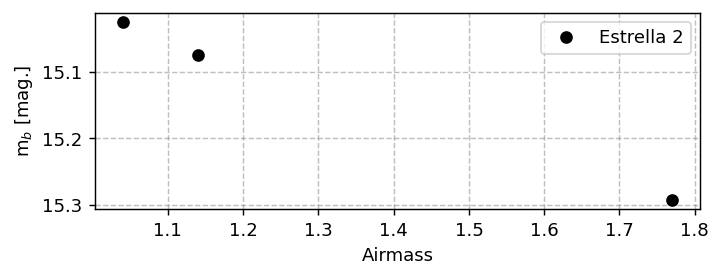

In [ ]:
id_estrella = 2
filtro = 'b'
# Filtro el pandas de fotometría para quedarme con una sola estrella en un determinado filtro.
ff = fotometria [ (fotometria['id'] == id_estrella) & (fotometria['filtro'] == filtro) ]

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (6, 2), dpi = 130 )

ax.plot ( ff['airmass'], ff['magnitud'], 'ko', label = 'Estrella ' + str(id) )
ax.set_xlabel ( 'Airmass' )
ax.set_ylabel ( 'm$_' + filtro +'$ [mag.]' )

plt.legend()
plt.gca().invert_yaxis()
plt.grid ( color = 'gray', linestyle = '--', alpha = 0.5 )

plt.show()

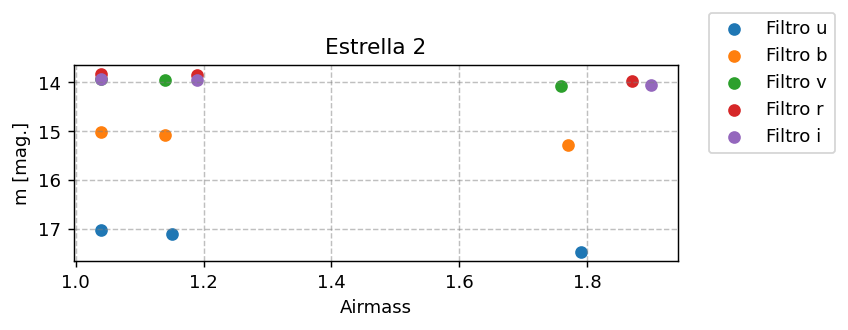

In [ ]:
id_estrella = 2
filtro = 'b'

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (6, 2), dpi = 130 )
plt.title ( 'Estrella ' + str(id) )

for F in [ 'u', 'b', 'v', 'r', 'i' ]:
    ff = fotometria.loc [ (fotometria['id'] == id_estrella) & (fotometria['filtro'] == F) ]
    ax.scatter ( ff['airmass'], ff['magnitud'], label = 'Filtro ' + F  )
    
ax.set_xlabel ( 'Airmass' )
ax.set_ylabel ( 'm [mag.]' )

plt.legend ( loc = (1.05,0.55) )
plt.gca().invert_yaxis()
plt.grid ( color = 'gray', linestyle = '--', alpha = 0.5 )

plt.show()

### Ejemplo de ajuste numérico

In [ ]:
id_estrella = 2
filtro = 'u'

# Filtro el pandas de fotometría para quedarme con una sola estrella en un determinado filtro.
ff = fotometria [ (fotometria['id'] == id_estrella) & (fotometria['filtro'] == filtro) ]

In [117]:
r, cov = np.polyfit(ff['airmass'], ff['magnitud'], deg = 1, cov = True ) #esto es un arreglo de ajuste para aproximar por una recta las magnitudes de las estrellas
std = np.sqrt(np.diag(cov))

pendiente = r[0]
ordenada = r[1]
pendiente_e = std[0]
ordenada_e = std[1]

# Defino un cartel para poner en la figura con los parametros ajustados
label = 'y = (%4.2f$\pm$%4.2f)*x + (%4.2f$\pm$%4.2f)' %(pendiente, pendiente_e, ordenada, ordenada_e)
label

'y = (0.59$\\pm$0.02)*x + (16.43$\\pm$0.02)'

In [118]:
cov #En su diag principal tiene los errores para los parámetros (Matriz de covarianza // estadística)

array([[ 0.00032789, -0.00043501],
       [-0.00043501,  0.00061297]])

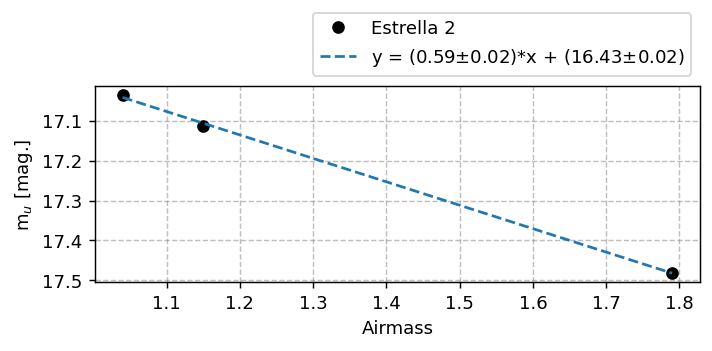

In [119]:
def fitted_line(x):
    return pendiente * x + ordenada

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (6, 2), dpi = 130 )

ax.plot ( ff['airmass'], ff['magnitud'], 'ko', label = 'Estrella ' + str(id) )
ax.plot ( ff['airmass'], fitted_line(ff['airmass']), '--', label = label )

ax.set_xlabel ( 'Airmass' )
ax.set_ylabel ( 'm$_' + filtro + '$ [mag.]' )

plt.legend(loc=(0.36,1.05))
plt.gca().invert_yaxis()
plt.grid ( color = 'gray', linestyle = '--', alpha = 0.5 )

plt.show()
#La estrella 3 tiene el problema que está muy al borde de la imagen, quizás la apertura sobresale de la imagen y eso hace que quede una recta ascendente.

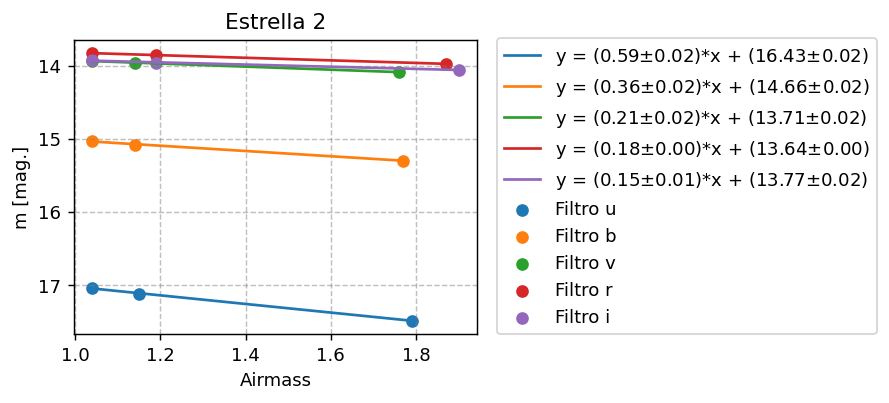

In [ ]:
from matplotlib.pyplot import cm

def fitted_line(x):
    return pendiente * x + ordenada

id = 2

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (4, 3), dpi = 130 )
plt.title ( 'Estrella ' + str(id) )

for F in [ 'u', 'b', 'v', 'r', 'i' ]:

    ff = fotometria.loc [ (fotometria['id'] == id) & (fotometria['filtro'] == F) ]

    r, cov = np.polyfit(ff['airmass'], ff['magnitud'], deg = 1, cov = True )
    std = np.sqrt(np.diag(cov))

    pendiente = r[0]
    ordenada = r[1]
    pendiente_e = std[0]
    ordenada_e = std[1]
    label = 'y = (%4.2f$\pm$%4.2f)*x + (%4.2f$\pm$%4.2f)' %(pendiente, pendiente_e, ordenada, ordenada_e)

    ax.scatter ( ff['airmass'], ff['magnitud'], label = 'Filtro ' + F)
    ax.plot ( ff['airmass'], fitted_line(ff['airmass']), '-', label = label)
    
ax.set_xlabel ( 'Airmass' )
ax.set_ylabel ( 'm [mag.]' )

plt.legend ( ncol = 1, loc = (1.05,0) )
plt.gca().invert_yaxis()
plt.grid ( color = 'gray', linestyle = '--', alpha = 0.5 )

plt.show()

In [130]:
#Mauskerramienta misteriosa que usaremos más tarde

for F in [ 'u', 'b', 'v', 'r', 'i' ]:
    kappasum = 0
    kappaerr = 0
    
    for id in [1, 2, 4]:
        ff = fotometria.loc [ (fotometria['id'] == id) & (fotometria['filtro'] == F) ]
        
        r, cov = np.polyfit(ff['airmass'], ff['magnitud'], deg = 1, cov = True )
        std = np.sqrt(np.diag(cov))

        pendiente = r[0]
        ordenada = r[1]
        pendiente_e = std[0]
        ordenada_e = std[1]
    
        kappasum = kappasum + pendiente
        kappaerr = kappaerr + pendiente_e
               
    kappa_prom = kappasum/3
    kappaerr_prom = kappaerr/3
    print ('<\kappa_', F, '> = ', kappa_prom, '\pm', kappaerr_prom)

<\kappa_ u > =  0.5457462493185729 \pm 0.09394803330010089
<\kappa_ b > =  0.3308204602945511 \pm 0.05379039094413645
<\kappa_ v > =  0.18913096335856286 \pm 0.014865588038496849
<\kappa_ r > =  0.17002520540750857 \pm 0.0015848406846149649
<\kappa_ i > =  0.11678172902787325 \pm 0.025639108454767346


**Más ejemplos: [Fitting a line:astropy](https://docs.astropy.org/en/stable/modeling/example-fitting-line.html).**